This notebook is to display and compare the results I personally conducted and the results found by the paper. This is to make sure what we're getting is correct!

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [23]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [24]:
def plotStats( X, plots, xLabel, yLabel, title ):

    for label, plot in plots:
        plt.plot(x, plot, label=label )
    
    plt.grid()
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

## Cache Size Experiment

The reported experiment is this:

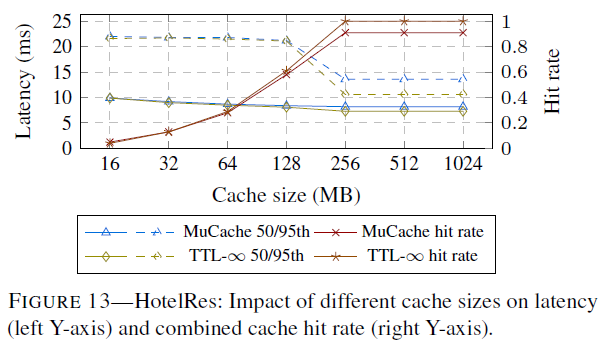

Our results are as follows:


In [ ]:
# NOT DONE YET
x = [16,32,64,128,256,512,1024]

# m510
_, mucache_out = getStats("hotel-md_10req.json")
_, ttl_out = getStats("hotel-md-upper_10req.json")

# d430
# _, mucache50, mucache95 = getStats("hotel-md.json")
# _, ttl50, ttl95 = getStats("hotel-md-upper.json")

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Cache size (MB)", "Latency (s)", "Cache Size Comparisons" )

In [ ]:
# Also plot the hitrate
#print( mucache_out["hit_rate"] )
plots = [["MuCache", [ float( hr["frontend"] ) for hr in mucache_out["hit_rate"]]],
         ["TTL", [ float( hr["frontend"] ) for hr in ttl_out["hit_rate"]]]
        ]
plotStats( x, plots, "Cache size (MB)", "Hit Rate", "Hit Rate Comparisons" )

### Analysis
Comparing the paper's graphs to our graphs, we can see that MuCache and TTL share similar values which is the same for the charts. However, the recorded trends in the paper such as the increase are not reflected in these experiments. In addition, the latency is in terms of seconds, not milliseconds.

## Microbenchmark

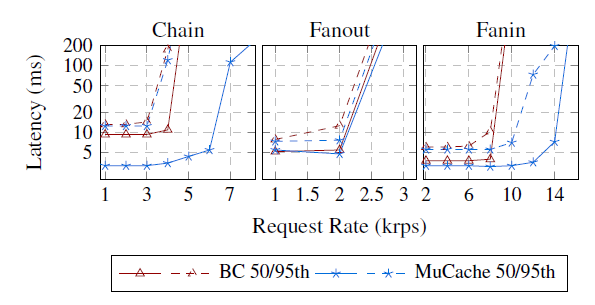

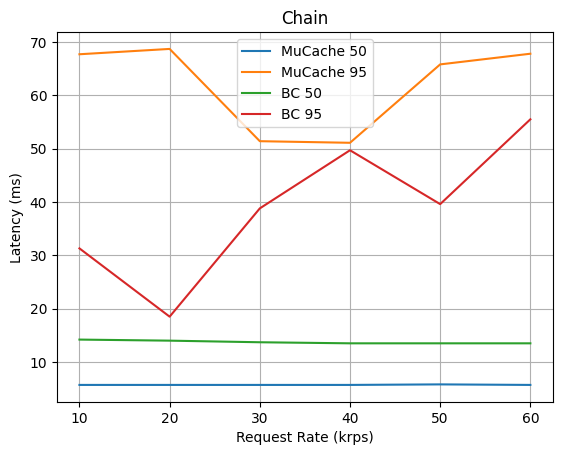

In [25]:
# Chain
x, mucache_out = getStats( "chain_10req.json" )
_, bc_out = getStats( "chain-baseline_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain" )

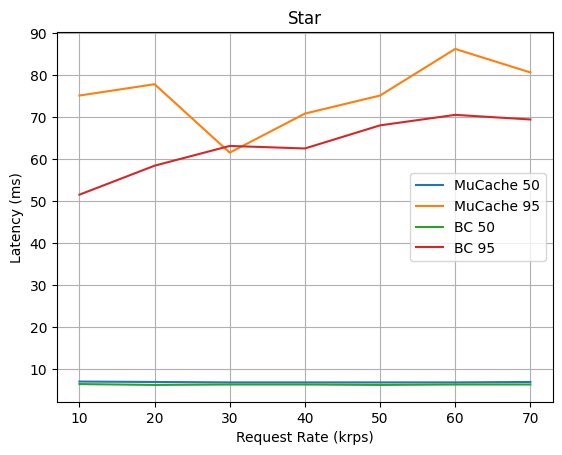

In [38]:
# Fanout/Star
x, mucache_out = getStats( "star_10req.json" )
_, bc_out = getStats( "star-baseline_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star" )

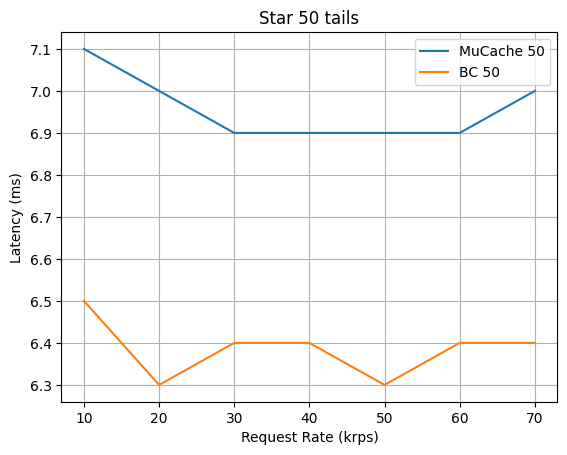

In [40]:
# Plot only 50's for star
plots_50 = [["MuCache 50", mucache_out["50"]],
         ["BC 50", bc_out["50"]],]
plotStats( x, plots_50, "Request Rate (krps)", "Latency (ms)", "Star 50 tails" )

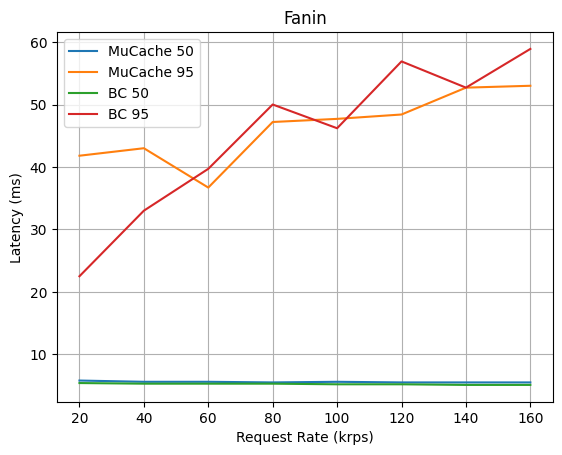

In [43]:
# Fanin
x, mucache_out = getStats( "fanin_10req.json" )
_, bc_out = getStats( "fanin-baseline_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin" )

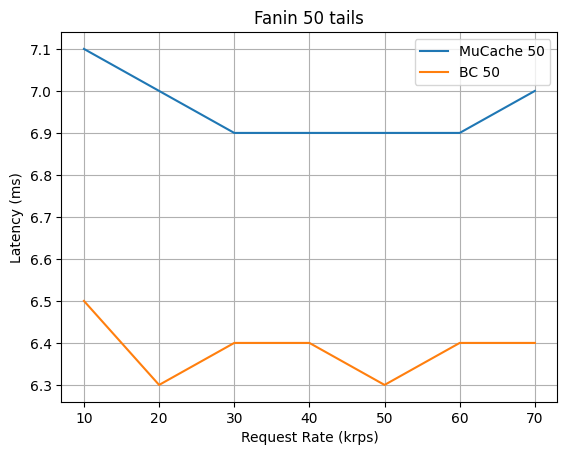

In [42]:
# Plot only 50's for Fanin
plots_50 = [["MuCache 50", mucache_out["50"]],
         ["BC 50", bc_out["50"]],]
plotStats( x, plots_50, "Request Rate (krps)", "Latency (ms)", "Fanin 50 tails" )

### Analysis
Compared to the paper's results, it seems like only for chain, MuCache 50 performs better than the BC 50. However, besides that, MuCache performs equally or worse than the baseline.

## Hit Rate

In [ ]:
# TODO new file
# Fanin
x, mucache_out = getStats( "fanin_10req.json" )
_, bc_out = getStats( "fanin-baseline_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]SocialMedia
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Fanin" )

## Real World Applications

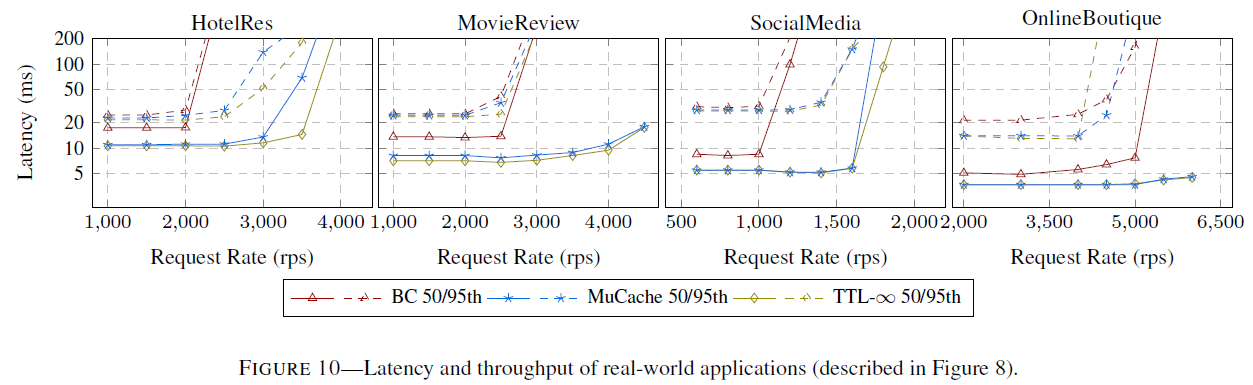

In [ ]:
# HotelRes NOT DONE YET
x, mucache_out = getStats( "hotel_10req.json" )
_, bc_out = getStats( "hotel-baseline_10req.json" )
_, ttl_out = getStats( "hotel-upper_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "HotelRes" )

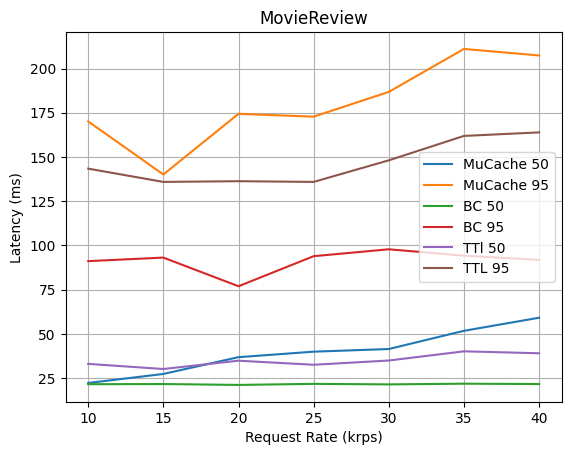

In [28]:
# MovieReview
x, mucache_out = getStats( "movie_10req.json" )
_, bc_out = getStats( "movie-baseline_10req.json" )
_, ttl_out = getStats( "movie-upper_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "MovieReview" )

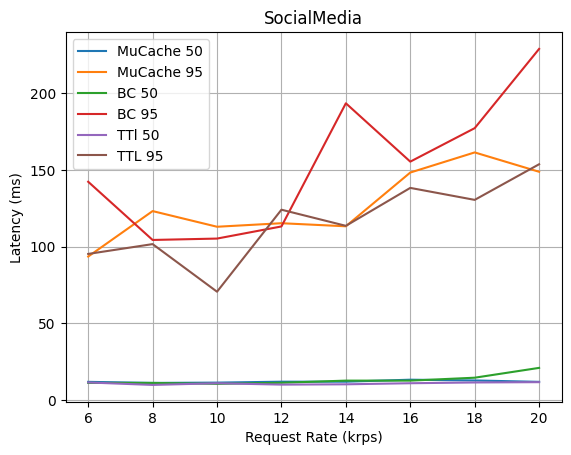

In [44]:
# SocialMedia
x, mucache_out = getStats( "social_10req.json" )
_, bc_out = getStats( "social-baseline_10req.json" )
_, ttl_out = getStats( "social-upper_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "SocialMedia" )

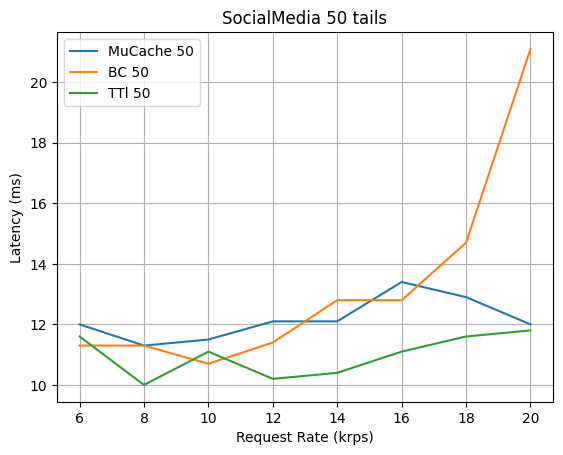

In [45]:
plots_50 = [["MuCache 50", mucache_out["50"]],
         ["BC 50", bc_out["50"]],
         ["TTl 50", ttl_out["50"]],]
plotStats( x, plots_50, "Request Rate (krps)", "Latency (ms)", "SocialMedia 50 tails" )

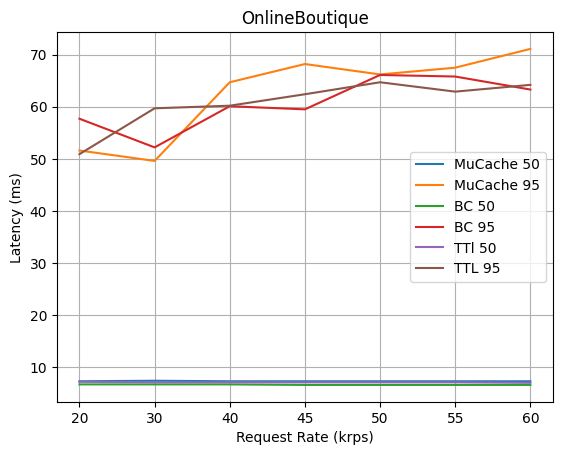

In [46]:
# OnlineBoutique
x, mucache_out = getStats( "boutique_10req.json" )
_, bc_out = getStats( "boutique-baseline_10req.json" )
_, ttl_out = getStats( "boutique-upper_10req.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTl 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "OnlineBoutique" )

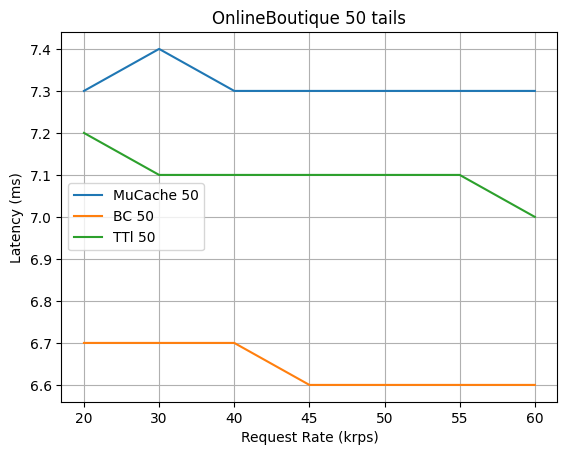

In [47]:
plots_50 = [["MuCache 50", mucache_out["50"]],
         ["BC 50", bc_out["50"]],
         ["TTl 50", ttl_out["50"]],]
plotStats( x, plots_50, "Request Rate (krps)", "Latency (ms)", "OnlineBoutique 50 tails" )

### Analysis
It seems like the results are pretty similar with the results from higher request rates, which is worrying. In addition, the basecase still performs better than MuCache in general.

## Different TTL Baselines

DIDNT DO, DO IT